In [1]:
# 1) ensure Python can see your project root
import os, sys, time
import numpy as np
import matplotlib.pyplot as plt

project_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

print("→ Added to sys.path:", project_root)
print("→ cwd is:", os.getcwd())

from environments.auv_env.auv_env    import AUVEnv
from environments.auv_env.auv_config import AUVEnvConfig
from agents.auv_dqn_agent    import AuvDQNAgent
from agents.enhanced_dqn_agent import EnhancedDQNAgent
from agents.td3_agent       import TD3Agent, train_td3
from agents.dqn_agent      import train_dqn
from environments.grid_env.grid_utils     import plot_rewards
from utils.shared_utils import evaluate_agent
from utils.graphics_utils import record_headless

→ Added to sys.path: /Users/eirikvarnes/code/auv-rl-project
→ cwd is: /Users/eirikvarnes/code/auv-rl-project/notebooks


In [2]:
static_cfg = AUVEnvConfig()
static_env = AUVEnv(static_cfg)

static_agent = AuvDQNAgent(
    static_env,
    hidden_dims=[64, 64],
    lr=1e-3,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=64,
    buffer_size=20000,
    target_update=20,
)


DQN Training: 100%|██████████| 500/500 [02:10<00:00,  3.85it/s, Reward=401.8, ε=0.082]  


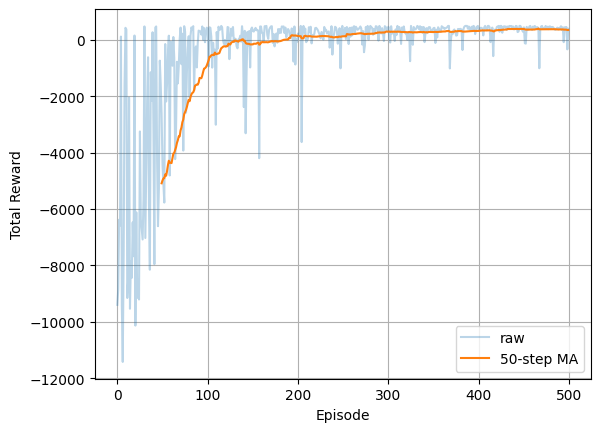

In [3]:
rewards = train_dqn(static_env, static_agent, episodes=500, max_steps= 500)
plot_rewards(rewards, window=50)
static_agent.save("../models/static_auv_dqn.pth")

In [4]:
static_agent.load("../models/static_auv_dqn.pth")

In [5]:
record_headless(static_env, static_agent, out_path='../gifs/static_auv.gif')

Headless recording saved to ../gifs/static_auv.gif


In [6]:
sr, avg_steps = evaluate_agent(static_env, static_agent, episodes = 500, max_steps=500)
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

Success rate: 98.4%, Avg steps: 34.3


In [7]:
actions = [
    (0.15,  0.0),  # forward
    (0.15,  0.15),  # forward + left
    (0.15, -0.15),  # forward + right
    (0.0,  0.15),  # in-place left turn
    (0.0, -0.15),  # in-place right turn
]


random_cfg = AUVEnvConfig(random_map=True, 
                          dock_radius=0.2, 
                          spawn_clearance=0.5,
                          wall_penalty_coeff=5.0,
                          wall_thresh=1.0,
                          collision_penalty=5.0, 
                          turn_penalty_coeff= 1.0,
                          progress_coeff= 1.0,
                          use_discrete_actions = actions,
                          )

random_env = AUVEnv(random_cfg)

random_agent = AuvDQNAgent(
    random_env,
    hidden_dims=[256,256,128],
    lr=1e-3,
    gamma=0.95,
    epsilon_start=1.0,
    epsilon_min=0.01,
    epsilon_decay=0.995,
    batch_size=128,
    buffer_size=20000,
    target_update=40,
)


DQN Training: 100%|██████████| 3000/3000 [10:16<00:00,  4.86it/s, Reward=386.7, ε=0.010]  


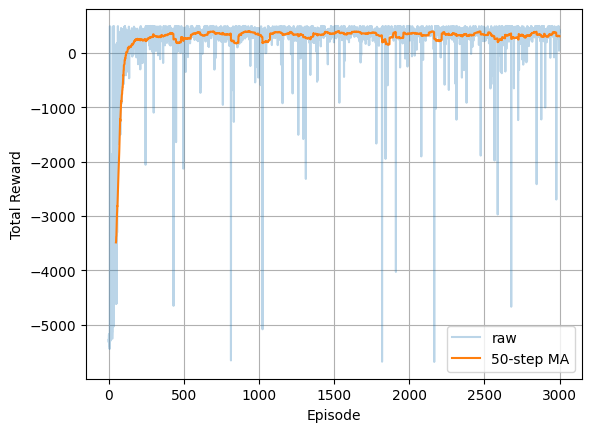

In [8]:
rewards = train_dqn(random_env, random_agent, episodes=3000, max_steps=1000)
plot_rewards(rewards, window=50)
random_agent.save("../models/random_auv_dqn.pth")

In [9]:
record_headless(random_env, random_agent, out_path='../gifs/random_auv.gif')

Headless recording saved to ../gifs/random_auv.gif


In [10]:
random_agent.load("../models/random_auv_dqn.pth")

In [11]:
sr, avg_steps = evaluate_agent(random_env, 
                               random_agent, 
                               episodes = 500, 
                               max_steps=500
                               )

print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

Success rate: 94.2%, Avg steps: 33.5


In [12]:
test_random_env = AUVEnv(random_cfg)


In [13]:
record_headless(test_random_env, random_agent, out_path='../gifs/test_random_auv.gif')

Headless recording saved to ../gifs/test_random_auv.gif


In [14]:
sr, avg_steps = evaluate_agent(test_random_env, 
                               random_agent, 
                               episodes = 100, 
                               max_steps=500
                               )

print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

Success rate: 95.0%, Avg steps: 31.4


# **Realistic Env**

In [3]:
cfg = AUVEnvConfig(use_discrete_actions=False)
td3_env = AUVEnv(cfg)

td3_agent = TD3Agent(td3_env)

rewards = train_td3(td3_env, td3_agent, episodes=1000, max_steps=200, noise=0.1)


Enhanced TD3: 100%|██████████| 1000/1000 [07:22<00:00,  2.26it/s, Ep R=403.59, it/s=112.7] 


In [4]:
record_headless(td3_env, td3_agent, out_path='../gifs/realistic_auv.gif')

Headless recording saved to ../gifs/realistic_auv.gif


In [ ]:
sr, avg_steps = evaluate_agent(td3_env,
                               td3_agent, 
                               episodes = 500, 
                               max_steps=500
                               )
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

In [ ]:
cfg = AUVEnvConfig(use_discrete_actions=False,
                   random_map=True, 
                   dock_radius=0.2, 
                   spawn_clearance=0.5,
                   wall_penalty_coeff=5.0,
                   wall_thresh=1.0,
                   collision_penalty=5.0, 
                   turn_penalty_coeff= 1.0,
                   progress_coeff= 1.0,
                  )

td3_random_env = AUVEnv(cfg)

# 2) Create the TD3 agent
td3_random_agent = TD3Agent(td3_random_env)

rewards = train_td3(td3_random_env, td3_random_agent, episodes=1000, max_steps=300, noise=0.1)


Enhanced TD3:  21%|██        | 207/1000 [05:00<20:41,  1.57s/it, Ep R=-1007.04, it/s=188.2]

In [ ]:
record_headless(td3_random_env, td3_random_agent, out_path='../gifs/random_td3_auv.gif')

Headless recording saved to ../gifs/random_td3_auv.gif


In [ ]:
sr, avg_steps = evaluate_agent(td3_random_env,
                               td3_random_agent, 
                               episodes = 500, 
                               max_steps=500
                               )
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

In [ ]:
cfg = AUVEnvConfig(use_discrete_actions=False,
                   use_physics=True)

real_env = AUVEnv(cfg)

# 2) Create the TD3 agent
real_agent = TD3Agent(real_env)

rewards = train_td3(real_env, real_agent, episodes=1000, max_steps=1000, noise=0.1)


TD3 Training:  43%|████▎     | 433/1000 [14:58<19:35,  2.07s/it, Ep Reward=-10194.40] 


KeyboardInterrupt: 

In [ ]:
record_headless(real_env, real_agent, out_path='../gifs/real_td3_auv.gif')

In [ ]:
sr, avg_steps = evaluate_agent(real_env,
                               real_agent, 
                               episodes = 500, 
                               max_steps=500
                               )
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")

In [ ]:
cfg = AUVEnvConfig(use_discrete_actions=False,
                   use_physics=True,
                   random_map=True,)

real_env = AUVEnv(cfg)

# 2) Create the TD3 agent
real_agent = TD3Agent(real_env)

rewards = train_td3(real_env, real_agent, episodes=1000, max_steps=1000, noise=0.1)


In [ ]:
sr, avg_steps = evaluate_agent(real_env,
                               real_agent, 
                               episodes = 500, 
                               max_steps=500
                               )
print(f"Success rate: {sr*100:.1f}%, Avg steps: {avg_steps:.1f}")